# Detecção de Fraude em Transações de Cartão de Crédito

**Autor:** Cientista de Dados (Risco de Crédito & Fraude Financeira)
**Abordagem:** classificação binária fortemente desbalanceada (~0,17% de fraude).

## Contexto de negócio
Em fraude financeira, **acurácia é uma métrica inútil**: um modelo que classifica tudo como
"legítimo" atinge >99,8% de acurácia e não detecta nenhuma fraude. O que importa é o
**trade-off de custo**:

- **Falso Negativo (FN):** fraude não detectada -> prejuízo financeiro direto + risco reputacional.
- **Falso Positivo (FP):** transação legítima bloqueada -> atrito com o cliente, custo de análise manual.

Por isso usamos **PR-AUC (Average Precision)**, **Recall da classe 1**, **F1 da classe 1** e **ROC-AUC**.
Como FN tende a ser mais caro que FP, priorizamos **Recall alto** no ajuste de limiar.

## Diretrizes seguidas
1. **Anti-leakage:** scaler e SMOTE são ajustados (`fit`) apenas no treino, dentro do pipeline.
2. **Métricas de negócio** em vez de acurácia global.
3. **`imblearn.pipeline.Pipeline`** para encadear pré-processamento + balanceamento + estimador.
4. **Reprodutibilidade:** `random_state=42` em todas as operações estocásticas.

### Roteiro
1. EDA
2. Pré-processamento e engenharia de atributos
3. Treino e comparação de 3 modelos (Validação Cruzada Estratificada)
4. Otimização do limiar de decisão
5. Avaliação final consolidada
6. Interpretabilidade com SHAP

## 0. Imports e configurações globais

Carregamos todas as bibliotecas necessárias e fixamos a semente para reprodutibilidade.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import RobustScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


Ambiente configurado. RANDOM_STATE = 42


## 1. Contexto de Negócio e Análise Exploratória (EDA)

Carregamos o dataset diretamente da URL (clássico `creditcard.csv` do TensorFlow: 284.807 transações,
30 atributos — `Time`, `V1..V28` já anonimizados via PCA, `Amount` e o alvo `Class`).

**O que verificamos:**
- Tipos de dados e ausência de valores nulos.
- Distribuição de classes (tabela percentual + gráfico em escala logarítmica).
- Estatísticas de `Amount` e `Time` por classe — espera-se que fraudes ocorram em valores e janelas temporais distintas das legítimas.

In [2]:

URL = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(URL)

print(f"Dimensões: {df.shape[0]:,} linhas x {df.shape[1]} colunas\n")

print("Tipos de dados (contagem por tipo):")
print(df.dtypes.value_counts().to_string())

nulos = df.isnull().sum().sum()
print(f"\nTotal de valores nulos: {nulos}")
print(f"Total de valores duplicados: {df.duplicated().sum()}")

df.head()

Dimensões: 284,807 linhas x 31 colunas

Tipos de dados (contagem por tipo):
float64    30
int64       1

Total de valores nulos: 0
Total de valores duplicados: 1081


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


,contagem,percentual (%)
Legítima (0),284315,99.8273
Fraude (1),492,0.1727


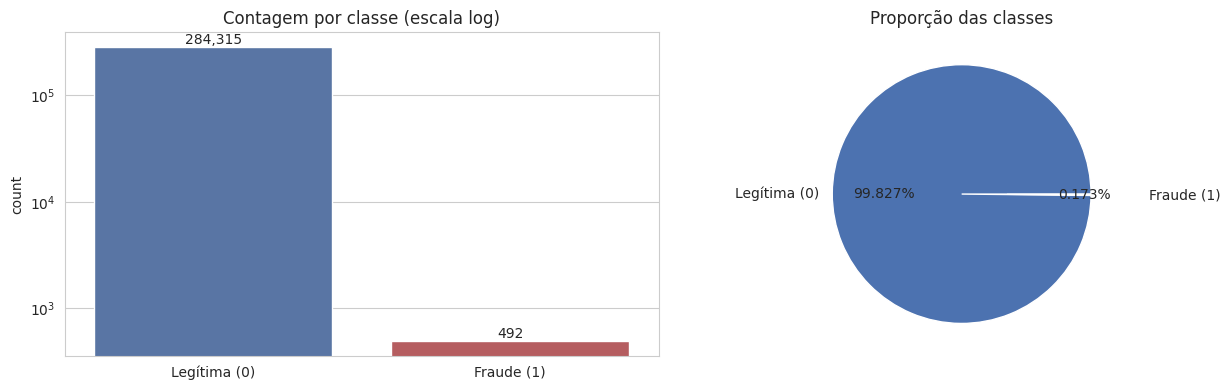

Razão de desbalanceamento: 1 fraude para cada 577 transações legítimas.


In [3]:

contagem = df["Class"].value_counts().rename("contagem")
percentual = (df["Class"].value_counts(normalize=True) * 100).round(4).rename("percentual (%)")
tabela_classes = pd.concat([contagem, percentual], axis=1)
tabela_classes.index = ["Legítima (0)", "Fraude (1)"]
display(tabela_classes)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# desbalanceamento brutal
sns.countplot(x="Class", data=df, ax=axes[0], palette=["#4C72B0", "#C44E52"])
axes[0].set_title("Contagem por classe (escala log)")
axes[0].set_yscale("log")
axes[0].set_xticklabels(["Legítima (0)", "Fraude (1)"])
axes[0].set_xlabel("")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=10)

axes[1].pie(tabela_classes["contagem"], labels=tabela_classes.index,
            autopct="%1.3f%%", colors=["#4C72B0", "#C44E52"], explode=[0, 0.35])
axes[1].set_title("Proporção das classes")

plt.tight_layout()
plt.show()

print(f"Razão de desbalanceamento: 1 fraude para cada "
      f"{int(contagem[0] / contagem[1]):,} transações legítimas.")

Legítima (0)  Fraude (1)
Amount count     284315.00      492.00
       mean          88.29      122.21
       std          250.11      256.68
       min            0.00        0.00
       25%            5.65        1.00
       50%           22.00        9.25
       75%           77.05      105.89
       max        25691.16     2125.87
Time   count     284315.00      492.00
       mean       94838.20    80746.81
       std        47484.02    47835.37
       min            0.00      406.00
       25%        54230.00    41241.50
       50%        84711.00    75568.50
       75%       139333.00   128483.00
       max       172792.00   170348.00

Mediana de Amount — Legítima: R$ 22.00 | Fraude: R$ 9.25


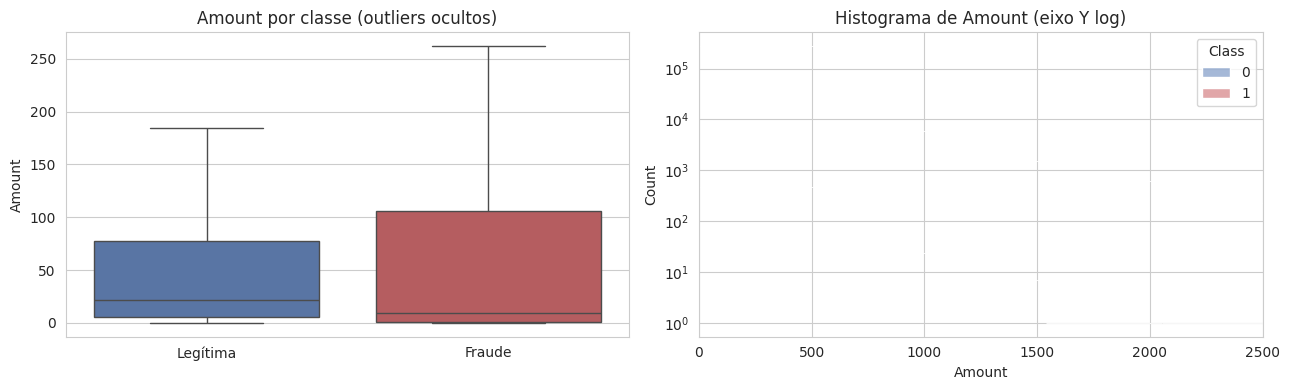

Cobertura temporal: 0.0h a 48.0h


In [4]:

desc = df.groupby("Class")[["Amount", "Time"]].describe().T
desc.columns = ["Legítima (0)", "Fraude (1)"]
display(desc.round(2))

print("Mediana de Amount — Legítima: R$ {:.2f} | Fraude: R$ {:.2f}".format(
    df.loc[df.Class == 0, "Amount"].median(),
    df.loc[df.Class == 1, "Amount"].median()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(x="Class", y="Amount", data=df, ax=axes[0],
            showfliers=False, palette=["#4C72B0", "#C44E52"])
axes[0].set_title("Amount por classe (outliers ocultos)")
axes[0].set_xticklabels(["Legítima", "Fraude"])
axes[0].set_xlabel("")

sns.histplot(data=df, x="Amount", hue="Class", bins=50, ax=axes[1],
             log_scale=(False, True), palette=["#4C72B0", "#C44E52"])
axes[1].set_title("Histograma de Amount (eixo Y log)")
axes[1].set_xlim(0, 2500)

plt.tight_layout()
plt.show()

# Time é o tempo em segundos desde a primeira transação (2 dias de coleta)
print(f"Cobertura temporal: {df['Time'].min()/3600:.1f}h a {df['Time'].max()/3600:.1f}h")

**Leitura da EDA:** o desbalanceamento severo inviabiliza acurácia global e exige técnicas de balanceamento e/ou ponderação. As fraudes concentram-se em valores menores e distribuem-se de forma heterogênea no tempo.

---

## 2. Pré-processamento e Engenharia de Atributos

- **`Amount`:** distribuição assimétrica à direita (muitos outliers). Foi aplicado `np.log1p` (transformação `log(1+x)`) via `FunctionTransformer`, que comprime caudas sem descartar dados.
- **`Time`:** Aplicou-se `RobustScaler` (mediana/IQR) — robusto a outliers, ao contrário do `StandardScaler`.
- **`V1..V28`:** já são componentes principais escalonadas; passam direto (`remainder="passthrough"`).
- **Split 80/20 estratificado** ANTES de qualquer `fit` de scaler/resampler.

> **Anti-leakage:** todo o `ColumnTransformer` e o `SMOTE` ficam *dentro* do pipeline e são ajustados apenas com `X_train`. Portanto o conjunto de teste nunca influencia as estatísticas de normalização nem as amostras sintéticas.

In [5]:
df["Amount_log"] = np.log1p(df["Amount"])

X = df.drop(columns=["Class"])
y = df["Class"].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Treino: {X_train.shape} | fraudes: {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"Teste : {X_test.shape} | fraudes: {y_test.sum()} ({y_test.mean()*100:.3f}%)")

# 2.1 preprocessador
preprocessor = ColumnTransformer(
    transformers=[
        ("amount_log", FunctionTransformer(np.log1p, validate=False), ["Amount"]),
        ("time_robust", RobustScaler(), ["Time"]),
    ],
    remainder="passthrough",   # V1..V28 passam diretamente
)

print("\nPré-processador criado (será ajustado SOMENTE no treino, dentro do pipeline).")

Treino: (227845, 31) | fraudes: 394 (0.173%)
Teste : (56962, 31) | fraudes: 98 (0.172%)

Pré-processador criado (será ajustado SOMENTE no treino, dentro do pipeline).


## 3. Treinamento e Comparação de Modelos

Comparo três abordagens com **Validação Cruzada Estratificada (5 folds)** — a estratificação é essencial para que cada fold contenha fraudes.

| Modelo | Estratégia de desbalanceamento |
|---|---|
| Baseline — Regressão Logística | `class_weight='balanced'` |
| Modelo 2 — Random Forest | `SMOTE` no pipeline (gera fraude sintética só no treino de cada fold) |
| Modelo 3 — XGBoost | `scale_pos_weight` = razão negativos/positivos |

Métricas de CV: **Average Precision (PR-AUC)**, **ROC-AUC**, precision/recall/F1 da classe 1.

In [6]:
# 3.1 Definição dos modelos e do esquema de validação cruzada

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}  (negativos / positivos no treino)")

models = {
    "LogReg (balanced)": ImbPipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000,
                                   random_state=RANDOM_STATE)),
    ]),

    "RandomForest + SMOTE": ImbPipeline([
        ("prep", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", RandomForestClassifier(n_estimators=200, max_depth=None,
                                       random_state=RANDOM_STATE, n_jobs=-1)),
    ]),

    "XGBoost (scale_pos_weight)": ImbPipeline([
        ("prep", preprocessor),
        ("clf", XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=5,
                              scale_pos_weight=scale_pos_weight,
                              eval_metric="aucpr", random_state=RANDOM_STATE,
                              n_jobs=-1)),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"pr_auc": "average_precision", "roc_auc": "roc_auc",
           "precision": "precision", "recall": "recall", "f1": "f1"}

scale_pos_weight = 577.29  (negativos / positivos no treino)


In [7]:
# 3.2 Validação cruzada estratificada (5 folds)
cv_results = {}
for name, pipe in models.items():
    print(f"Treinando/CV: {name} ...")
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    cv_results[name] = {m: res["test_" + m].mean() for m in scoring}
    cv_results[name]["pr_auc_std"] = res["test_pr_auc"].std()

cv_df = pd.DataFrame(cv_results).T
cv_df = cv_df[["pr_auc", "pr_auc_std", "roc_auc", "precision", "recall", "f1"]]
cv_df.columns = ["PR-AUC (média)", "PR-AUC (std)", "ROC-AUC", "Precision (c1)", "Recall (c1)", "F1 (c1)"]
display(cv_df.round(4))

best_name = cv_df["PR-AUC (média)"].idxmax()
print(f"\nMelhor modelo por PR-AUC em CV: {best_name}")

Treinando/CV: LogReg (balanced) ...
Treinando/CV: RandomForest + SMOTE ...
Treinando/CV: XGBoost (scale_pos_weight) ...


,PR-AUC (média),PR-AUC (std),ROC-AUC,Precision (c1),Recall (c1),F1 (c1)
LogReg (balanced),0.7583,0.0515,0.9814,0.0613,0.9087,0.1149
RandomForest + SMOTE,0.8421,0.0264,0.9767,0.8849,0.7995,0.8383
XGBoost (scale_pos_weight),0.8476,0.0186,0.9798,0.8932,0.8173,0.8520



Melhor modelo por PR-AUC em CV: XGBoost (scale_pos_weight)


In [8]:
# 3.3 Ajuste final de cada modelo no treino COMPLETO
fitted = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    print(f"{name} ajustado no treino completo.")

best_model = fitted[best_name]
print(f"\nModelo campeão: {best_name}")

LogReg (balanced) ajustado no treino completo.
RandomForest + SMOTE ajustado no treino completo.
XGBoost (scale_pos_weight) ajustado no treino completo.

Modelo campeão: XGBoost (scale_pos_weight)


## 4. Otimização do Limiar de Decisão (Threshold Tuning)

O limiar padrão 0.5 raramente é ótimo em cenários desbalanceados. Aqui:

1. Geramos a **curva Precision-Recall** no conjunto de **teste**.
2. Variamos o limiar de **0,10 a 0,90** (passo 0,05) e medimos Precision/Recall/F1 da fraude.
3. Identificamos dois candidatos:
   - limiar que **maximiza o F1** (equilíbrio);
   - limiar que **garante Recall >= 85%** (prioriza não deixar fraude passar).

**Trade-off de negócio:** um FN (fraude não detectada) custa o valor da transação + chargeback,
enquanto um FP custa uma análise manual e possível atrito. Como FN é tipicamente mais caro,
adotamos o **limiar de Recall >= 85%** como decisão operacional.

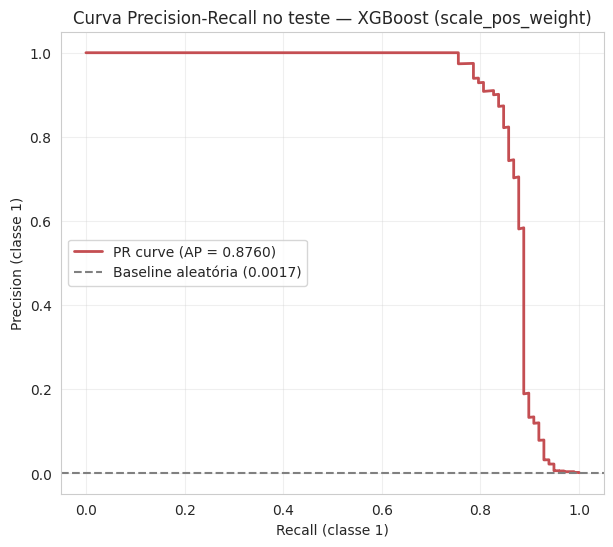

In [9]:
# 4.1 Curva Precision-Recall do modelo campeão
y_proba = best_model.predict_proba(X_test)[:, 1]   # probabilidade da classe 1 (fraude)
ap = average_precision_score(y_test, y_proba)

prec, rec, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(rec, prec, color="#C44E52", lw=2, label=f"PR curve (AP = {ap:.4f})")
plt.axhline(y_test.mean(), ls="--", color="gray",
            label=f"Baseline aleatória ({y_test.mean():.4f})")
plt.xlabel("Recall (classe 1)")
plt.ylabel("Precision (classe 1)")
plt.title(f"Curva Precision-Recall no teste — {best_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

,limiar,precision_1,recall_1,f1_1
0,0.10,0.7778,0.8571,0.8155
1,0.15,0.8384,0.8469,0.8426
2,0.20,0.8469,0.8469,0.8469
3,0.25,0.8557,0.8469,0.8513
4,0.30,0.8557,0.8469,0.8513
5,0.35,0.8557,0.8469,0.8513
6,0.40,0.8646,0.8469,0.8557
7,0.45,0.8737,0.8469,0.8601
8,0.50,0.8723,0.8367,0.8542
9,0.55,0.8723,0.8367,0.8542


[A] Limiar que maximiza F1 = 0.75 -> F1=0.8617, Precision=0.9000, Recall=0.8265
[B] Limiar com Recall >= 85% = 0.10 -> Precision=0.7778, Recall=0.8571, F1=0.8155


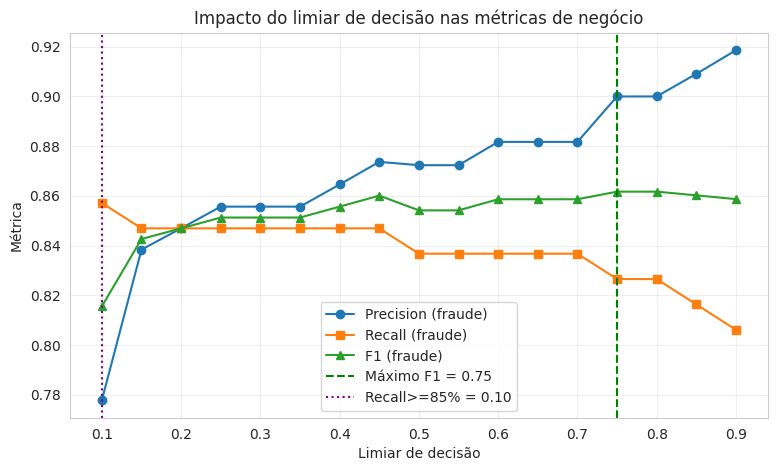

In [10]:
# 4.2 Varredura do limiar de 0.10 a 0.90 (passo 0.05)
thresholds = np.round(np.arange(0.10, 0.95, 0.05), 2)

rows = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    rows.append({
        "limiar": t,
        "precision_1": precision_score(y_test, y_pred_t, zero_division=0),
        "recall_1": recall_score(y_test, y_pred_t, zero_division=0),
        "f1_1": f1_score(y_test, y_pred_t, zero_division=0),
    })

thr_df = pd.DataFrame(rows)
display(thr_df.round(4))

# Candidato A: maximiza F1
best_f1_row = thr_df.loc[thr_df["f1_1"].idxmax()]

#Candidato B: menor limiar que garante Recall >= 0.85
cand_recall85 = thr_df[thr_df["recall_1"] >= 0.85]
thr_recall85 = cand_recall85.iloc[0] if len(cand_recall85) else None

print(f"[A] Limiar que maximiza F1 = {best_f1_row['limiar']:.2f} "
      f"-> F1={best_f1_row['f1_1']:.4f}, Precision={best_f1_row['precision_1']:.4f}, "
      f"Recall={best_f1_row['recall_1']:.4f}")

if thr_recall85 is not None:
    print(f"[B] Limiar com Recall >= 85% = {thr_recall85['limiar']:.2f} "
          f"-> Precision={thr_recall85['precision_1']:.4f}, "
          f"Recall={thr_recall85['recall_1']:.4f}, F1={thr_recall85['f1_1']:.4f}")

plt.figure(figsize=(9, 5))
plt.plot(thr_df["limiar"], thr_df["precision_1"], marker="o", label="Precision (fraude)")
plt.plot(thr_df["limiar"], thr_df["recall_1"], marker="s", label="Recall (fraude)")
plt.plot(thr_df["limiar"], thr_df["f1_1"], marker="^", label="F1 (fraude)")
plt.axvline(best_f1_row["limiar"], color="green", ls="--",
            label=f"Máximo F1 = {best_f1_row['limiar']:.2f}")
if thr_recall85 is not None:
    plt.axvline(thr_recall85["limiar"], color="purple", ls=":",
                label=f"Recall>=85% = {thr_recall85['limiar']:.2f}")
plt.xlabel("Limiar de decisão")
plt.ylabel("Métrica")
plt.title("Impacto do limiar de decisão nas métricas de negócio")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [11]:
# 4.3 Definição do limiar operacional
# N (fraude não detectada) é mais caro que FP (análise manual), portanto o Recall >= 85% foi priorizado quando possível.
if thr_recall85 is not None:
    decision_threshold = float(thr_recall85["limiar"])
    print(f"Limiar operacional escolhido: {decision_threshold:.2f} (garante Recall >= 85%)")
else:
    decision_threshold = float(best_f1_row["limiar"])
    print(f"Limiar operacional escolhido: {decision_threshold:.2f} (máximo F1)")

y_pred_best = (y_proba >= decision_threshold).astype(int)
print(f"Precision(c1)={precision_score(y_test, y_pred_best):.4f} | "
      f"Recall(c1)={recall_score(y_test, y_pred_best):.4f} | "
      f"F1(c1)={f1_score(y_test, y_pred_best):.4f}")

Limiar operacional escolhido: 0.10 (garante Recall >= 85%)
Precision(c1)=0.7778 | Recall(c1)=0.8571 | F1(c1)=0.8155


## 5. Avaliação Final Consolidada

- Tabela comparativa dos três modelos no **teste** (Precision, Recall, F1 da classe 1, PR-AUC, ROC-AUC).
- Matrizes de confusão (normalizada e não normalizada) do **campeão** no **limiar ótimo**.
- Curvas ROC e Precision-Recall de todos os modelos sobrepostas.

In [12]:
# 5.1 Tabela comparativa no conjunto de teste (limiar padrão 0.50)

test_metrics = []
for name, pipe in fitted.items():
    p = pipe.predict_proba(X_test)[:, 1]
    pred = (p >= 0.50).astype(int)
    test_metrics.append({
        "Modelo": name,
        "Precision (c1)": precision_score(y_test, pred, zero_division=0),
        "Recall (c1)": recall_score(y_test, pred, zero_division=0),
        "F1 (c1)": f1_score(y_test, pred, zero_division=0),
        "PR-AUC": average_precision_score(y_test, p),
        "ROC-AUC": roc_auc_score(y_test, p),
    })

metrics_df = pd.DataFrame(test_metrics).set_index("Modelo")

# Linha extra: campeão no limiar operacional otimizado
metrics_df.loc[f"{best_name} @ limiar {decision_threshold:.2f}"] = {
    "Precision (c1)": precision_score(y_test, y_pred_best, zero_division=0),
    "Recall (c1)": recall_score(y_test, y_pred_best, zero_division=0),
    "F1 (c1)": f1_score(y_test, y_pred_best, zero_division=0),
    "PR-AUC": ap,
    "ROC-AUC": roc_auc_score(y_test, y_proba),
}

display(metrics_df.round(4))

,Precision (c1),Recall (c1),F1 (c1),PR-AUC,ROC-AUC
Modelo,,,,,
LogReg (balanced),0.0601,0.9184,0.1129,0.7113,0.9712
RandomForest + SMOTE,0.8804,0.8265,0.8526,0.8732,0.9816
XGBoost (scale_pos_weight),0.8723,0.8367,0.8542,0.8760,0.9775
XGBoost (scale_pos_weight) @ limiar 0.10,0.7778,0.8571,0.8155,0.8760,0.9775


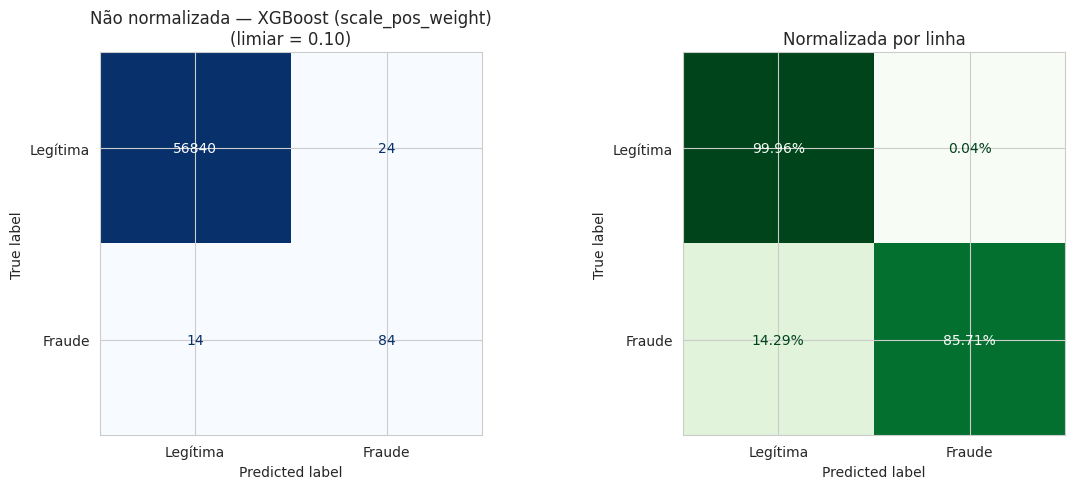

VP (fraudes detectadas) : 84
FN (fraudes perdidas)   : 14
FP (falsos alarmes)     : 24
VN (legítimas corretas) : 56840


In [13]:
# 5.2 Matrizes de confusão do campeão no limiar ótimo
cm = confusion_matrix(y_test, y_pred_best)
cm_norm = confusion_matrix(y_test, y_pred_best, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm, display_labels=["Legítima", "Fraude"]).plot(
    ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
axes[0].set_title(f"Não normalizada — {best_name}\n(limiar = {decision_threshold:.2f})")

ConfusionMatrixDisplay(cm_norm, display_labels=["Legítima", "Fraude"]).plot(
    ax=axes[1], cmap="Greens", values_format=".2%", colorbar=False)
axes[1].set_title("Normalizada por linha")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"VP (fraudes detectadas) : {tp}")
print(f"FN (fraudes perdidas)   : {fn}")
print(f"FP (falsos alarmes)     : {fp}")
print(f"VN (legítimas corretas) : {tn}")

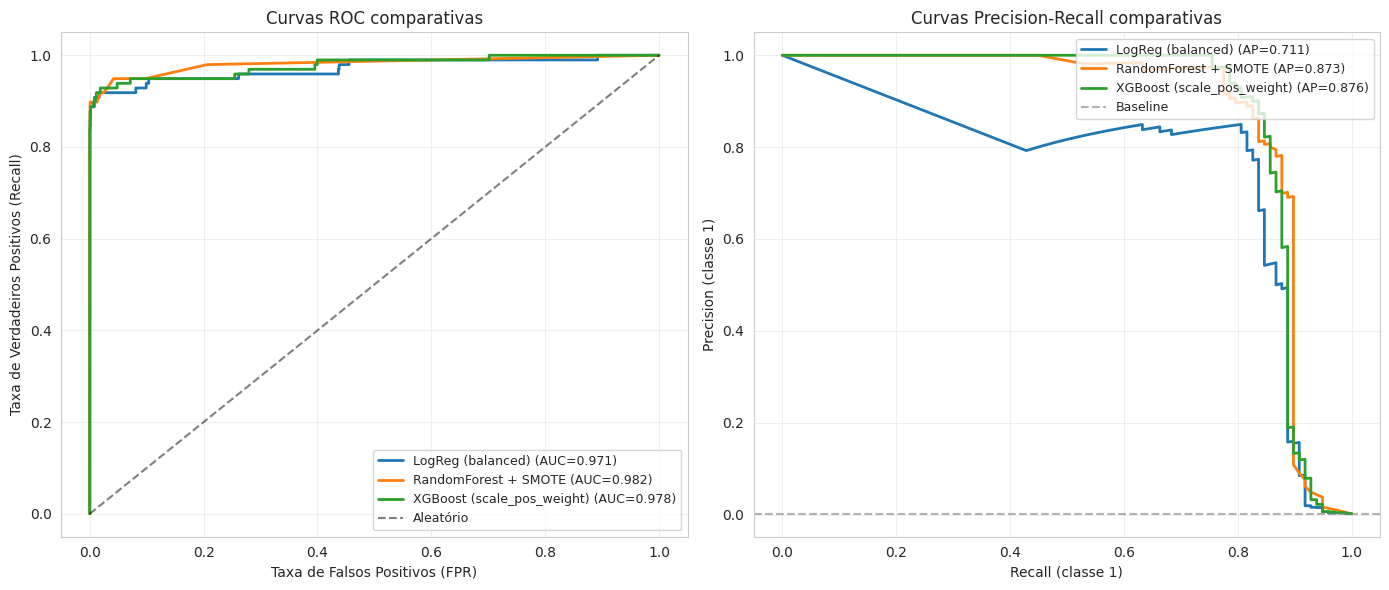

In [14]:
# 5.3 Curvas ROC e Precision-Recall sobrepostas
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, pipe in fitted.items():
    p = pipe.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, lw=2,
                 label=f"{name} (AUC={roc_auc_score(y_test, p):.3f})")

    pr, rc, _ = precision_recall_curve(y_test, p)
    axes[1].plot(rc, pr, lw=2,
                 label=f"{name} (AP={average_precision_score(y_test, p):.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Aleatório")
axes[0].set_xlabel("Taxa de Falsos Positivos (FPR)")
axes[0].set_ylabel("Taxa de Verdadeiros Positivos (Recall)")
axes[0].set_title("Curvas ROC comparativas")
axes[0].legend(loc="lower right", fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].axhline(y_test.mean(), ls="--", color="gray", alpha=0.6, label="Baseline")
axes[1].set_xlabel("Recall (classe 1)")
axes[1].set_ylabel("Precision (classe 1)")
axes[1].set_title("Curvas Precision-Recall comparativas")
axes[1].legend(loc="upper right", fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Conclusão

- Regressão Logística (LogReg balanced): Embora atinja a taxa de captura mais elevada (Recall de 91,84%), a sua precisão é excessivamente baixa (6,01%), o que resulta num F1-score de apenas 0,1129 e num PR-AUC de 0,7113. Em termos operacionais, este modelo gera um volume incomportável de falsos positivos (transações legítimas bloqueadas por engano), inviabilizando a sua utilização prática num ambiente de produção.   
- Random Forest com SMOTE: Demonstrou um comportamento robusto, alcançando uma precisão de 88,04%, um Recall de 82,65% e o maior ROC-AUC da comparação (0,9816). Mostra ser uma abordagem sólida quando associada à criação de instâncias sintéticas no treino.  
- XGBoost com scale_pos_weight: Afirmou-se como o modelo de topo, registando o maior valor de PR-AUC (0,8760) e o melhor equilíbrio inicial com limiar padrão (0,50), obtendo uma precisão de 87,23%, Recall de 83,67% e F1-score de 0,8542.